# Credit Card Approval Prediction

## Epic 1: Data Collection

### Importing the Libraries

In [1]:
# Importing Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
)

from xgboost import XGBClassifier
import joblib

In [2]:
import matplotlib.pyplot as plt
print("Matplotlib imported successfully!")

Matplotlib imported successfully!


# Credit Card Approval Prediction

## Epic 1 : Data Collection

### Importing the Libraries

In [3]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

import joblib

print("Libraries Imported Successfully")

Libraries Imported Successfully


## Read the Dataset

In [4]:
application = pd.read_csv("../data/application_record.csv")
credit = pd.read_csv("../data/credit_record.csv")

print("Datasets Loaded Successfully")

Datasets Loaded Successfully


In [5]:
application.head()

,ID,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,DAYS_BIRTH,DAYS_EMPLOYED,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS
0,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2.0
1,5008805,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2.0
2,5008806,M,Y,Y,0,112500.0,Working,Secondary / secondary special,Married,House / apartment,-21474,-1134,1,0,0,0,Security staff,2.0
3,5008808,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-19110,-3051,1,0,1,1,Sales staff,1.0
4,5008809,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-19110,-3051,1,0,1,1,Sales staff,1.0


In [6]:
credit.head()

,ID,MONTHS_BALANCE,STATUS
0,5001711,0,X
1,5001711,-1,0
2,5001711,-2,0
3,5001711,-3,0
4,5001712,0,C


In [7]:
print(application.shape)
print(credit.shape)

(438557, 18)
(1048575, 3)


In [8]:
application.info()

<class 'pandas.DataFrame'>
RangeIndex: 438557 entries, 0 to 438556
Data columns (total 18 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   ID                   438557 non-null  int64  
 1   CODE_GENDER          438557 non-null  str    
 2   FLAG_OWN_CAR         438557 non-null  str    
 3   FLAG_OWN_REALTY      438557 non-null  str    
 4   CNT_CHILDREN         438557 non-null  int64  
 5   AMT_INCOME_TOTAL     438557 non-null  float64
 6   NAME_INCOME_TYPE     438557 non-null  str    
 7   NAME_EDUCATION_TYPE  438557 non-null  str    
 8   NAME_FAMILY_STATUS   438557 non-null  str    
 9   NAME_HOUSING_TYPE    438557 non-null  str    
 10  DAYS_BIRTH           438557 non-null  int64  
 11  DAYS_EMPLOYED        438557 non-null  int64  
 12  FLAG_MOBIL           438557 non-null  int64  
 13  FLAG_WORK_PHONE      438557 non-null  int64  
 14  FLAG_PHONE           438557 non-null  int64  
 15  FLAG_EMAIL           438557 

In [9]:
credit.info()

<class 'pandas.DataFrame'>
RangeIndex: 1048575 entries, 0 to 1048574
Data columns (total 3 columns):
 #   Column          Non-Null Count    Dtype
---  ------          --------------    -----
 0   ID              1048575 non-null  int64
 1   MONTHS_BALANCE  1048575 non-null  int64
 2   STATUS          1048575 non-null  str  
dtypes: int64(2), str(1)
memory usage: 24.0 MB


In [10]:
application.describe()

,ID,CNT_CHILDREN,AMT_INCOME_TOTAL,DAYS_BIRTH,DAYS_EMPLOYED,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,CNT_FAM_MEMBERS
count,4.385570e+05,438557.000000,4.385570e+05,438557.000000,438557.000000,438557.0,438557.000000,438557.000000,438557.000000,438557.000000
mean,6.022176e+06,0.427390,1.875243e+05,-15997.904649,60563.675328,1.0,0.206133,0.287771,0.108207,2.194465
std,5.716370e+05,0.724882,1.100869e+05,4185.030007,138767.799647,0.0,0.404527,0.452724,0.310642,0.897207
min,5.008804e+06,0.000000,2.610000e+04,-25201.000000,-17531.000000,1.0,0.000000,0.000000,0.000000,1.000000
25%,5.609375e+06,0.000000,1.215000e+05,-19483.000000,-3103.000000,1.0,0.000000,0.000000,0.000000,2.000000
50%,6.047745e+06,0.000000,1.607805e+05,-15630.000000,-1467.000000,1.0,0.000000,0.000000,0.000000,2.000000
75%,6.456971e+06,1.000000,2.250000e+05,-12514.000000,-371.000000,1.0,0.000000,1.000000,0.000000,3.000000
max,7.999952e+06,19.000000,6.750000e+06,-7489.000000,365243.000000,1.0,1.000000,1.000000,1.000000,20.000000


In [11]:
credit.describe()

,ID,MONTHS_BALANCE
count,1.048575e+06,1.048575e+06
mean,5.068286e+06,-1.913700e+01
std,4.615058e+04,1.402350e+01
min,5.001711e+06,-6.000000e+01
25%,5.023644e+06,-2.900000e+01
50%,5.062104e+06,-1.700000e+01
75%,5.113856e+06,-7.000000e+00
max,5.150487e+06,0.000000e+00


# Epic 2 : Visualizing and Analysing the Data

## Univariate Analysis

In [12]:
credit["STATUS"].value_counts()

STATUS
C    442031
0    383120
X    209230
1     11090
5      1693
2       868
3       320
4       223
Name: count, dtype: int64

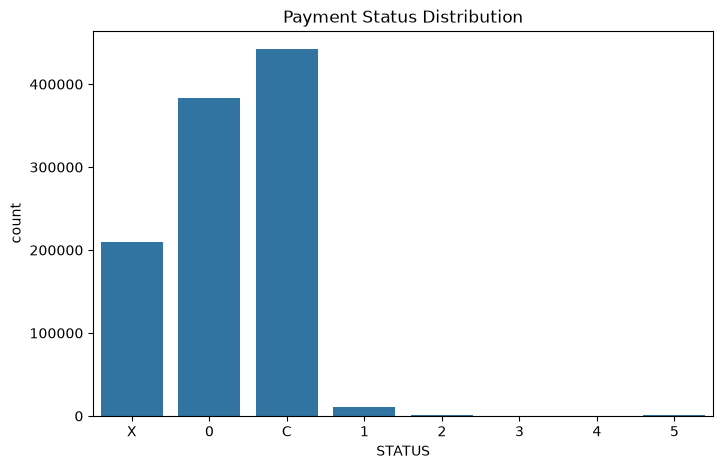

In [13]:
plt.figure(figsize=(8,5))
sns.countplot(x="STATUS", data=credit)
plt.title("Payment Status Distribution")
plt.show()

In [14]:
application["CODE_GENDER"].value_counts()

CODE_GENDER
F    294440
M    144117
Name: count, dtype: int64

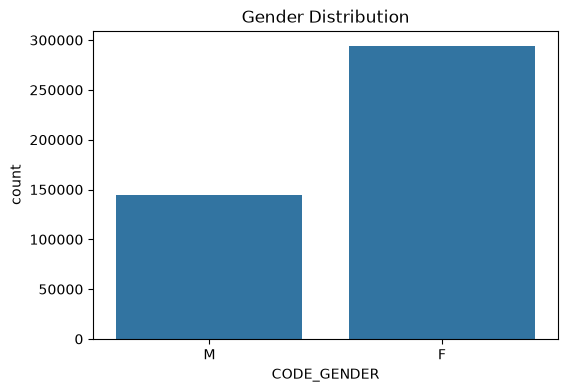

In [15]:
plt.figure(figsize=(6,4))
sns.countplot(x="CODE_GENDER", data=application)
plt.title("Gender Distribution")
plt.show()

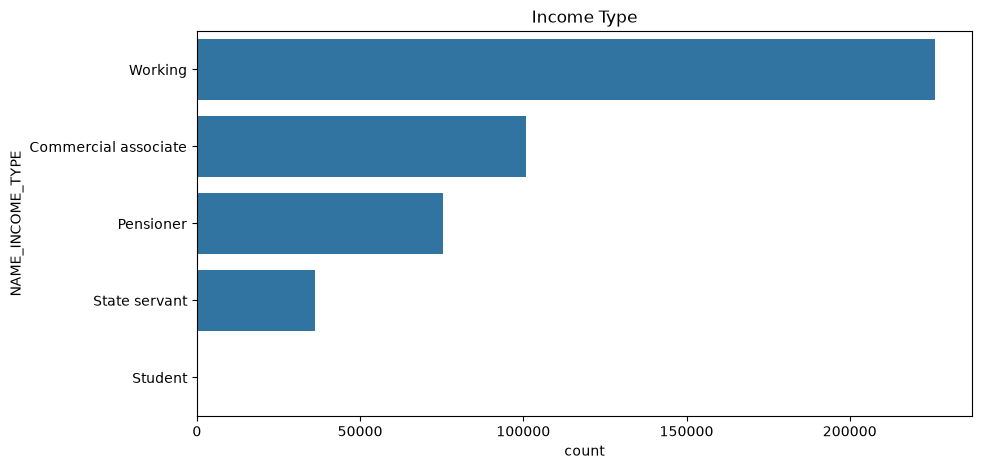

In [16]:
plt.figure(figsize=(10,5))
sns.countplot(y="NAME_INCOME_TYPE", data=application)
plt.title("Income Type")
plt.show()

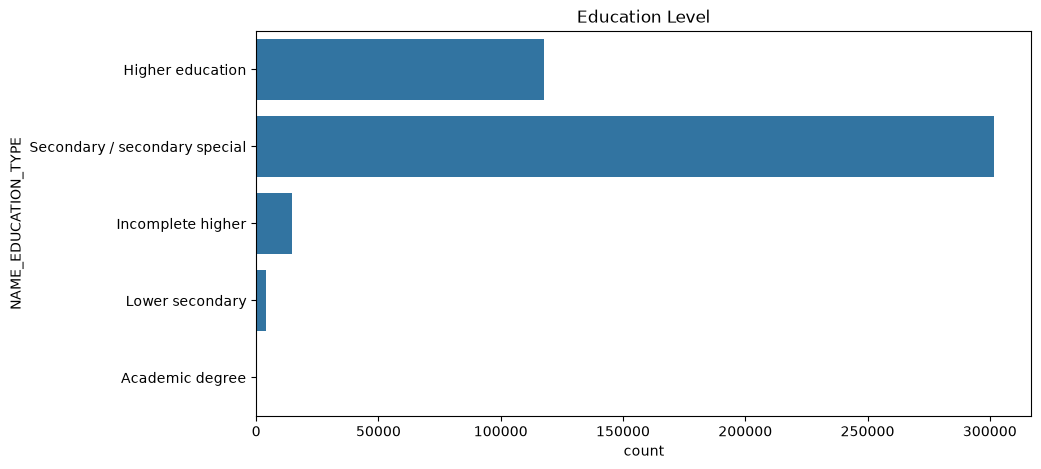

In [17]:
plt.figure(figsize=(10,5))
sns.countplot(y="NAME_EDUCATION_TYPE", data=application)
plt.title("Education Level")
plt.show()

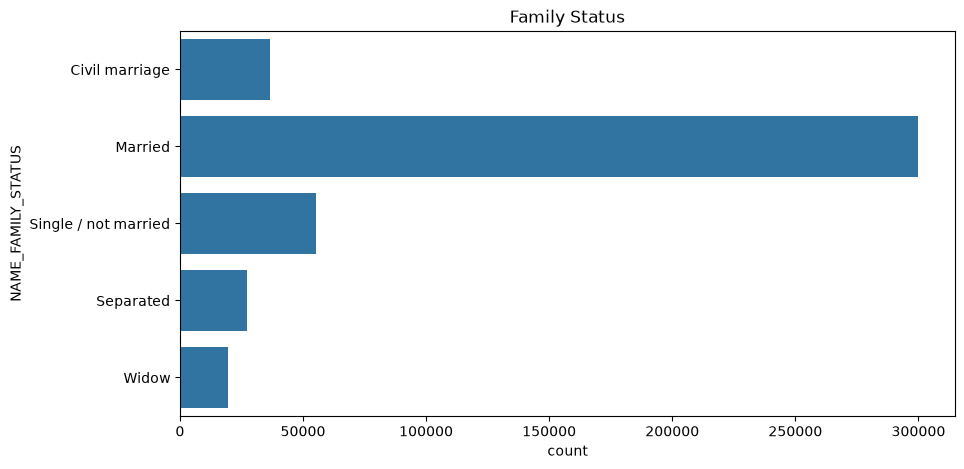

In [18]:
plt.figure(figsize=(10,5))
sns.countplot(y="NAME_FAMILY_STATUS", data=application)
plt.title("Family Status")
plt.show()

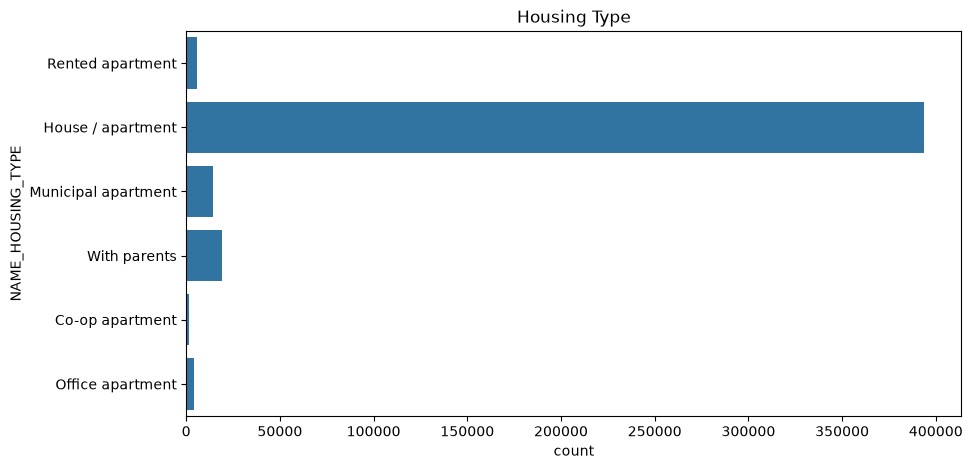

In [19]:
plt.figure(figsize=(10,5))
sns.countplot(y="NAME_HOUSING_TYPE", data=application)
plt.title("Housing Type")
plt.show()

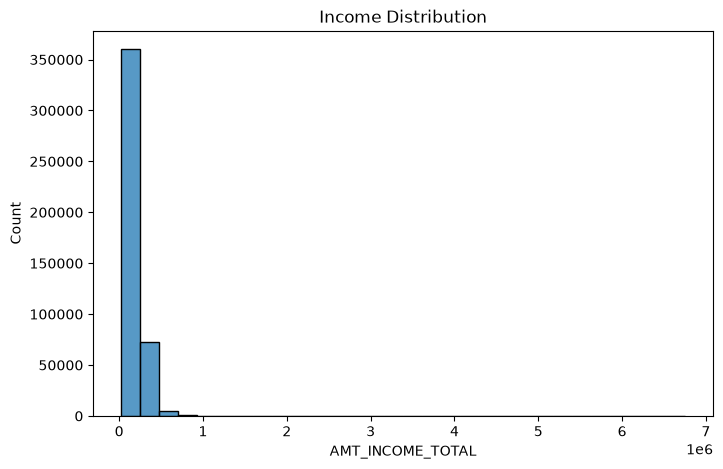

In [20]:
plt.figure(figsize=(8,5))
sns.histplot(application["AMT_INCOME_TOTAL"], bins=30)
plt.title("Income Distribution")
plt.show()

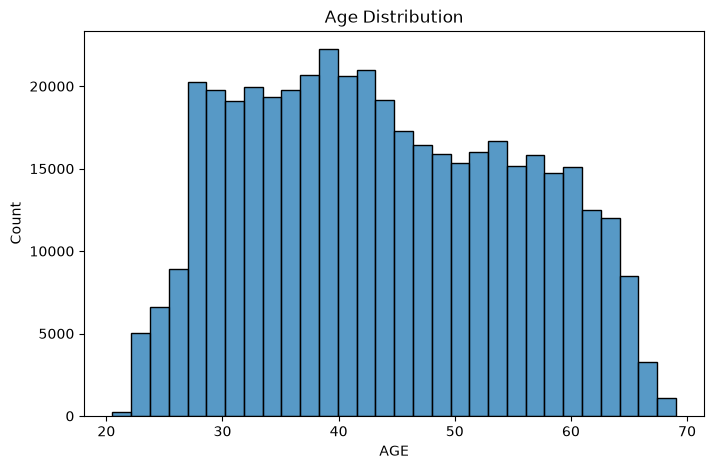

In [21]:
application["AGE"] = abs(application["DAYS_BIRTH"]) / 365

plt.figure(figsize=(8,5))
sns.histplot(application["AGE"], bins=30)
plt.title("Age Distribution")
plt.show()

## Multivariate Analysis

In [22]:
merged = application.merge(credit, on="ID", how="inner")

print(merged.shape)
merged.head()

(777715, 21)


,ID,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,...,DAYS_EMPLOYED,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,AGE,MONTHS_BALANCE,STATUS
0,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,...,-4542,1,1,0,0,NaN,2.0,32.890411,0,C
1,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,...,-4542,1,1,0,0,NaN,2.0,32.890411,-1,C
2,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,...,-4542,1,1,0,0,NaN,2.0,32.890411,-2,C
3,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,...,-4542,1,1,0,0,NaN,2.0,32.890411,-3,C
4,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,...,-4542,1,1,0,0,NaN,2.0,32.890411,-4,C


In [23]:
merged.select_dtypes(include=["int64", "float64"]).head()

,ID,CNT_CHILDREN,AMT_INCOME_TOTAL,DAYS_BIRTH,DAYS_EMPLOYED,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,CNT_FAM_MEMBERS,AGE,MONTHS_BALANCE
0,5008804,0,427500.0,-12005,-4542,1,1,0,0,2.0,32.890411,0
1,5008804,0,427500.0,-12005,-4542,1,1,0,0,2.0,32.890411,-1
2,5008804,0,427500.0,-12005,-4542,1,1,0,0,2.0,32.890411,-2
3,5008804,0,427500.0,-12005,-4542,1,1,0,0,2.0,32.890411,-3
4,5008804,0,427500.0,-12005,-4542,1,1,0,0,2.0,32.890411,-4


In [24]:
corr = merged.select_dtypes(include=["int64", "float64"]).corr()

corr.head()

,ID,CNT_CHILDREN,AMT_INCOME_TOTAL,DAYS_BIRTH,DAYS_EMPLOYED,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,CNT_FAM_MEMBERS,AGE,MONTHS_BALANCE
ID,1.000000,0.026269,-0.027597,0.042020,-0.025322,NaN,0.084800,0.006346,-0.056083,0.027375,-0.042020,0.005007
CNT_CHILDREN,0.026269,1.000000,0.039304,0.356177,-0.228945,NaN,0.042226,-0.018882,0.015726,0.892079,-0.356177,0.000913
AMT_INCOME_TOTAL,-0.027597,0.039304,1.000000,0.081231,-0.180674,NaN,-0.021229,0.018687,0.085776,0.031379,-0.081231,0.001831
DAYS_BIRTH,0.042020,0.356177,0.081231,1.000000,-0.608856,NaN,0.180658,-0.026717,0.100945,0.327750,-1.000000,0.035756
DAYS_EMPLOYED,-0.025322,-0.228945,-0.180674,-0.608856,1.000000,NaN,-0.243677,-0.013817,-0.082474,-0.227645,0.608856,-0.004222


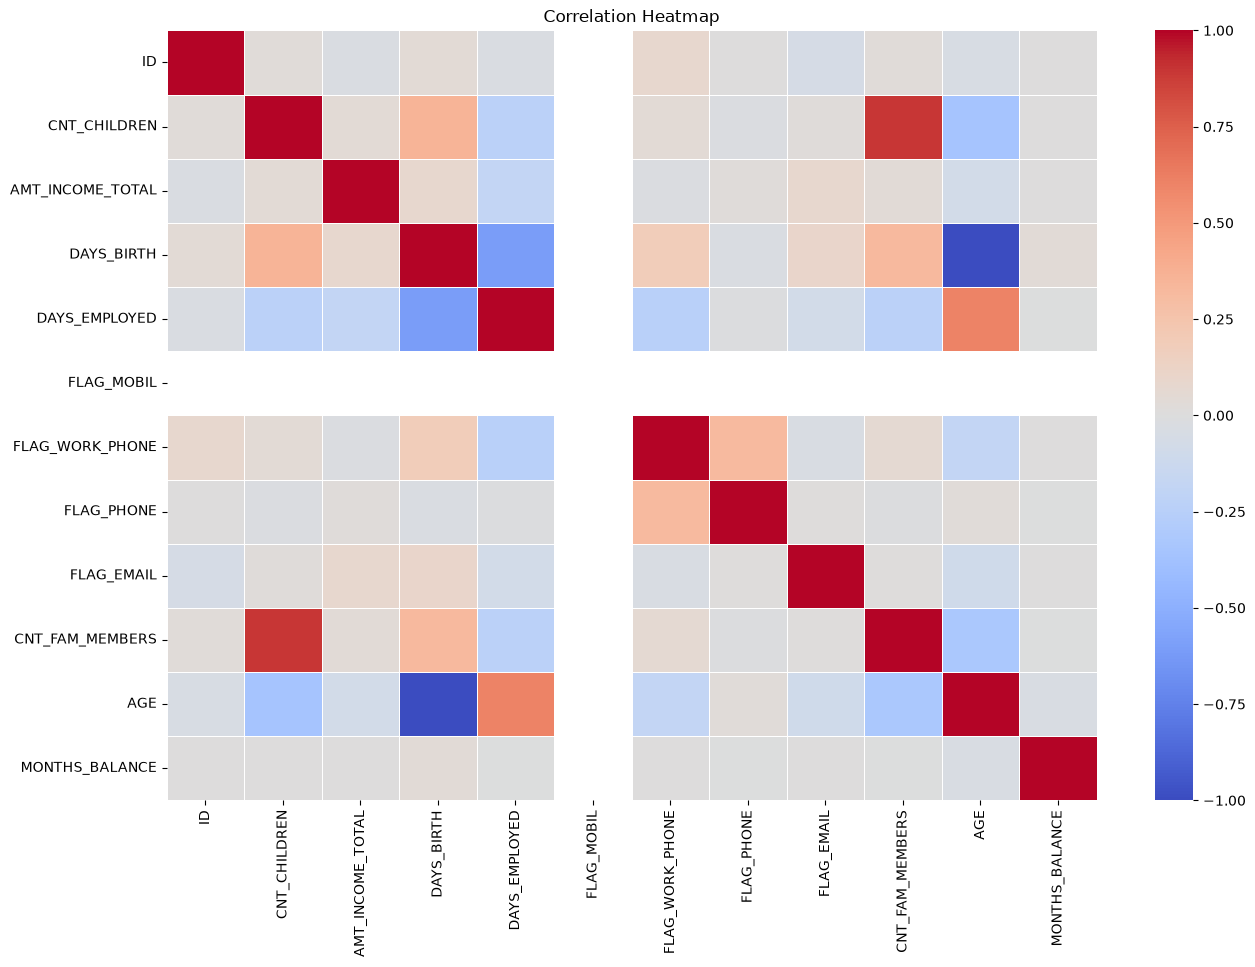

In [25]:
plt.figure(figsize=(15,10))

sns.heatmap(
    corr,
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Correlation Heatmap")
plt.show()

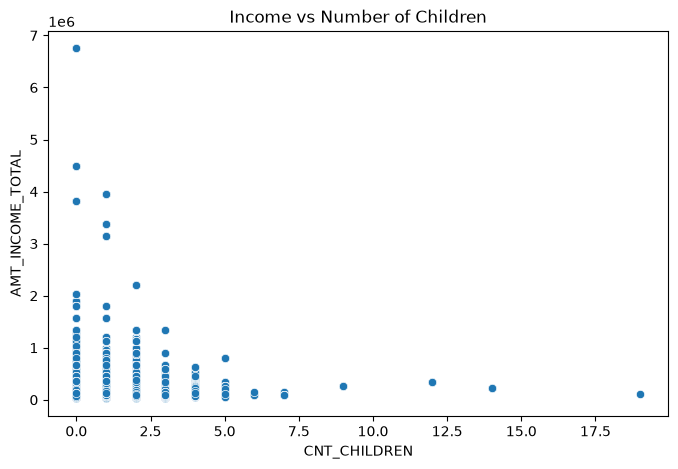

In [26]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    x="CNT_CHILDREN",
    y="AMT_INCOME_TOTAL",
    data=application
)

plt.title("Income vs Number of Children")
plt.show()

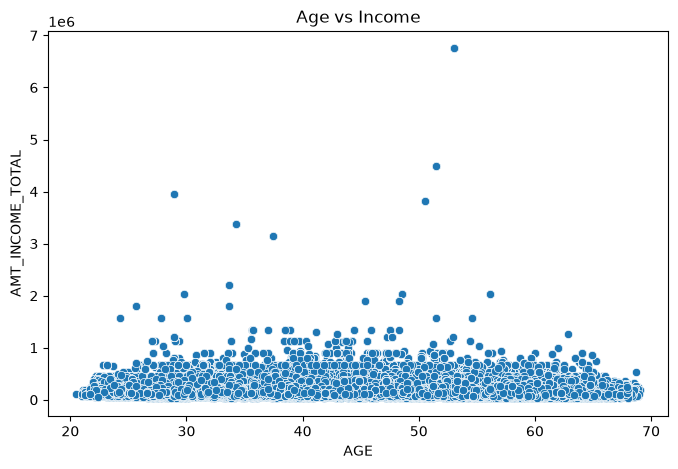

In [27]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    x="AGE",
    y="AMT_INCOME_TOTAL",
    data=application
)

plt.title("Age vs Income")
plt.show()

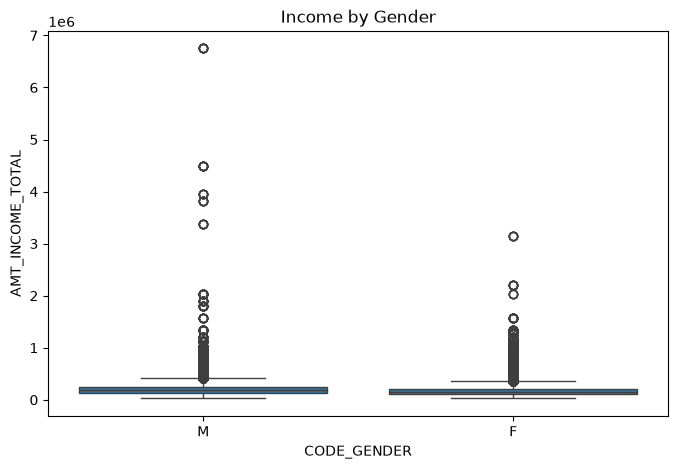

In [28]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x="CODE_GENDER",
    y="AMT_INCOME_TOTAL",
    data=application
)

plt.title("Income by Gender")
plt.show()

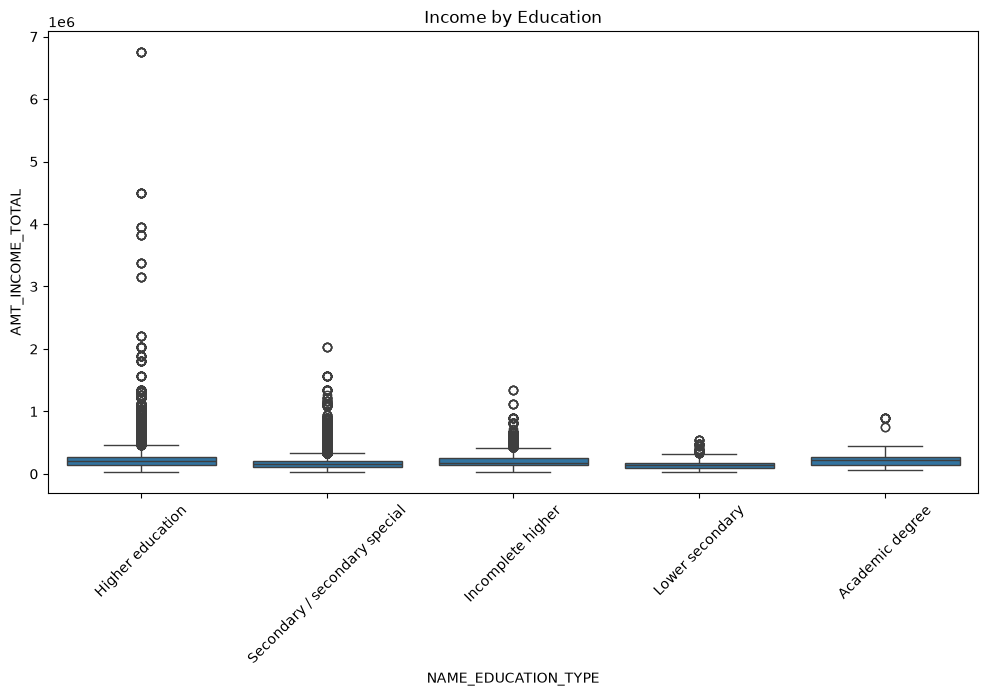

In [29]:
plt.figure(figsize=(12,6))

sns.boxplot(
    x="NAME_EDUCATION_TYPE",
    y="AMT_INCOME_TOTAL",
    data=application
)

plt.xticks(rotation=45)

plt.title("Income by Education")
plt.show()

## Descriptive Analysis

In [30]:
application.describe(include="all")

,ID,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,DAYS_BIRTH,DAYS_EMPLOYED,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,AGE
count,4.385570e+05,438557,438557,438557,438557.000000,4.385570e+05,438557,438557,438557,438557,438557.000000,438557.000000,438557.0,438557.000000,438557.000000,438557.000000,304354,438557.000000,438557.000000
unique,NaN,2,2,2,NaN,NaN,5,5,5,6,NaN,NaN,NaN,NaN,NaN,NaN,18,NaN,NaN
top,NaN,F,N,Y,NaN,NaN,Working,Secondary / secondary special,Married,House / apartment,NaN,NaN,NaN,NaN,NaN,NaN,Laborers,NaN,NaN
freq,NaN,294440,275459,304074,NaN,NaN,226104,301821,299828,393831,NaN,NaN,NaN,NaN,NaN,NaN,78240,NaN,NaN
mean,6.022176e+06,NaN,NaN,NaN,0.427390,1.875243e+05,NaN,NaN,NaN,NaN,-15997.904649,60563.675328,1.0,0.206133,0.287771,0.108207,NaN,2.194465,43.829876
std,5.716370e+05,NaN,NaN,NaN,0.724882,1.100869e+05,NaN,NaN,NaN,NaN,4185.030007,138767.799647,0.0,0.404527,0.452724,0.310642,NaN,0.897207,11.465836
min,5.008804e+06,NaN,NaN,NaN,0.000000,2.610000e+04,NaN,NaN,NaN,NaN,-25201.000000,-17531.000000,1.0,0.000000,0.000000,0.000000,NaN,1.000000,20.517808
25%,5.609375e+06,NaN,NaN,NaN,0.000000,1.215000e+05,NaN,NaN,NaN,NaN,-19483.000000,-3103.000000,1.0,0.000000,0.000000,0.000000,NaN,2.000000,34.284932
50%,6.047745e+06,NaN,NaN,NaN,0.000000,1.607805e+05,NaN,NaN,NaN,NaN,-15630.000000,-1467.000000,1.0,0.000000,0.000000,0.000000,NaN,2.000000,42.821918
75%,6.456971e+06,NaN,NaN,NaN,1.000000,2.250000e+05,NaN,NaN,NaN,NaN,-12514.000000,-371.000000,1.0,0.000000,1.000000,0.000000,NaN,3.000000,53.378082


In [31]:
credit.describe(include="all")

,ID,MONTHS_BALANCE,STATUS
count,1.048575e+06,1.048575e+06,1048575
unique,NaN,NaN,8
top,NaN,NaN,C
freq,NaN,NaN,442031
mean,5.068286e+06,-1.913700e+01,NaN
std,4.615058e+04,1.402350e+01,NaN
min,5.001711e+06,-6.000000e+01,NaN
25%,5.023644e+06,-2.900000e+01,NaN
50%,5.062104e+06,-1.700000e+01,NaN
75%,5.113856e+06,-7.000000e+00,NaN


In [32]:
application.nunique()

ID                     438510
CODE_GENDER                 2
FLAG_OWN_CAR                2
FLAG_OWN_REALTY             2
CNT_CHILDREN               12
AMT_INCOME_TOTAL          866
NAME_INCOME_TYPE            5
NAME_EDUCATION_TYPE         5
NAME_FAMILY_STATUS          5
NAME_HOUSING_TYPE           6
DAYS_BIRTH              16379
DAYS_EMPLOYED            9406
FLAG_MOBIL                  1
FLAG_WORK_PHONE             2
FLAG_PHONE                  2
FLAG_EMAIL                  2
OCCUPATION_TYPE            18
CNT_FAM_MEMBERS            13
AGE                     16379
dtype: int64

In [33]:
credit.nunique()

ID                45985
MONTHS_BALANCE       61
STATUS                8
dtype: int64

# Epic 3 : Data Pre-processing

## Drop Duplicate Records

In [34]:
print("Application duplicates:", application.duplicated().sum())
print("Credit duplicates:", credit.duplicated().sum())

Application duplicates: 0
Credit duplicates: 0


In [35]:
application = application.drop_duplicates()
credit = credit.drop_duplicates()

print(application.shape)
print(credit.shape)

(438557, 19)
(1048575, 3)


## Handling Missing Values

In [36]:
application.isnull().sum()

ID                          0
CODE_GENDER                 0
FLAG_OWN_CAR                0
FLAG_OWN_REALTY             0
CNT_CHILDREN                0
AMT_INCOME_TOTAL            0
NAME_INCOME_TYPE            0
NAME_EDUCATION_TYPE         0
NAME_FAMILY_STATUS          0
NAME_HOUSING_TYPE           0
DAYS_BIRTH                  0
DAYS_EMPLOYED               0
FLAG_MOBIL                  0
FLAG_WORK_PHONE             0
FLAG_PHONE                  0
FLAG_EMAIL                  0
OCCUPATION_TYPE        134203
CNT_FAM_MEMBERS             0
AGE                         0
dtype: int64

In [37]:
credit.isnull().sum()

ID                0
MONTHS_BALANCE    0
STATUS            0
dtype: int64

In [38]:
application.isnull().mean()*100

ID                      0.000000
CODE_GENDER             0.000000
FLAG_OWN_CAR            0.000000
FLAG_OWN_REALTY         0.000000
CNT_CHILDREN            0.000000
AMT_INCOME_TOTAL        0.000000
NAME_INCOME_TYPE        0.000000
NAME_EDUCATION_TYPE     0.000000
NAME_FAMILY_STATUS      0.000000
NAME_HOUSING_TYPE       0.000000
DAYS_BIRTH              0.000000
DAYS_EMPLOYED           0.000000
FLAG_MOBIL              0.000000
FLAG_WORK_PHONE         0.000000
FLAG_PHONE              0.000000
FLAG_EMAIL              0.000000
OCCUPATION_TYPE        30.601039
CNT_FAM_MEMBERS         0.000000
AGE                     0.000000
dtype: float64

In [39]:
credit.isnull().mean()*100

ID                0.0
MONTHS_BALANCE    0.0
STATUS            0.0
dtype: float64

## Data Cleaning

In [40]:
application.columns

Index(['ID', 'CODE_GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'CNT_CHILDREN',
       'AMT_INCOME_TOTAL', 'NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE',
       'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE', 'DAYS_BIRTH',
       'DAYS_EMPLOYED', 'FLAG_MOBIL', 'FLAG_WORK_PHONE', 'FLAG_PHONE',
       'FLAG_EMAIL', 'OCCUPATION_TYPE', 'CNT_FAM_MEMBERS', 'AGE'],
      dtype='str')

In [41]:
application["AGE"] = abs(application["DAYS_BIRTH"]) // 365

application["YEARS_EMPLOYED"] = abs(application["DAYS_EMPLOYED"]) // 365

In [42]:
application.head()

,ID,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,DAYS_BIRTH,DAYS_EMPLOYED,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,AGE,YEARS_EMPLOYED
0,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2.0,32,12
1,5008805,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2.0,32,12
2,5008806,M,Y,Y,0,112500.0,Working,Secondary / secondary special,Married,House / apartment,-21474,-1134,1,0,0,0,Security staff,2.0,58,3
3,5008808,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-19110,-3051,1,0,1,1,Sales staff,1.0,52,8
4,5008809,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-19110,-3051,1,0,1,1,Sales staff,1.0,52,8


In [43]:
application = application.drop(
    columns=["DAYS_BIRTH","DAYS_EMPLOYED"]
)

In [44]:
application.head()

,ID,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,AGE,YEARS_EMPLOYED
0,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,1,1,0,0,NaN,2.0,32,12
1,5008805,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,1,1,0,0,NaN,2.0,32,12
2,5008806,M,Y,Y,0,112500.0,Working,Secondary / secondary special,Married,House / apartment,1,0,0,0,Security staff,2.0,58,3
3,5008808,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,1,0,1,1,Sales staff,1.0,52,8
4,5008809,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,1,0,1,1,Sales staff,1.0,52,8


## Merge the Dataset

In [45]:
df = application.merge(
    credit,
    on="ID",
    how="inner"
)

df.head()

,ID,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,AGE,YEARS_EMPLOYED,MONTHS_BALANCE,STATUS
0,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,1,1,0,0,NaN,2.0,32,12,0,C
1,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,1,1,0,0,NaN,2.0,32,12,-1,C
2,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,1,1,0,0,NaN,2.0,32,12,-2,C
3,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,1,1,0,0,NaN,2.0,32,12,-3,C
4,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,1,1,0,0,NaN,2.0,32,12,-4,C


In [46]:
df.shape

(777715, 20)

## Feature Engineering

In [47]:
df["STATUS"].value_counts()

STATUS
C    329536
0    290654
X    145950
1      8747
5      1527
2       801
3       286
4       214
Name: count, dtype: int64

In [48]:
df["TARGET"] = df["STATUS"].replace({
    "X":0,
    "C":0,
    "0":0,
    "1":1,
    "2":1,
    "3":1,
    "4":1,
    "5":1
})

In [49]:
df[["STATUS","TARGET"]].head()

,STATUS,TARGET
0,C,0
1,C,0
2,C,0
3,C,0
4,C,0


In [50]:
df.drop(columns=["STATUS"], inplace=True)

## Handling Categorical Values

In [51]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

In [52]:
categorical = df.select_dtypes(include="object").columns

categorical

C:\Users\Rasmitha Kasvi\AppData\Local\Temp\ipykernel_18968\3242653156.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical = df.select_dtypes(include="object").columns


Index(['CODE_GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'NAME_INCOME_TYPE',
       'NAME_EDUCATION_TYPE', 'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE',
       'OCCUPATION_TYPE', 'TARGET'],
      dtype='str')

In [53]:
for col in categorical:
    df[col] = encoder.fit_transform(df[col])

In [54]:
df.head()

,ID,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,AGE,YEARS_EMPLOYED,MONTHS_BALANCE,TARGET
0,5008804,1,1,1,0,427500.0,4,1,0,4,1,1,0,0,18,2.0,32,12,0,0
1,5008804,1,1,1,0,427500.0,4,1,0,4,1,1,0,0,18,2.0,32,12,-1,0
2,5008804,1,1,1,0,427500.0,4,1,0,4,1,1,0,0,18,2.0,32,12,-2,0
3,5008804,1,1,1,0,427500.0,4,1,0,4,1,1,0,0,18,2.0,32,12,-3,0
4,5008804,1,1,1,0,427500.0,4,1,0,4,1,1,0,0,18,2.0,32,12,-4,0


In [55]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 777715 entries, 0 to 777714
Data columns (total 20 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   ID                   777715 non-null  int64  
 1   CODE_GENDER          777715 non-null  int64  
 2   FLAG_OWN_CAR         777715 non-null  int64  
 3   FLAG_OWN_REALTY      777715 non-null  int64  
 4   CNT_CHILDREN         777715 non-null  int64  
 5   AMT_INCOME_TOTAL     777715 non-null  float64
 6   NAME_INCOME_TYPE     777715 non-null  int64  
 7   NAME_EDUCATION_TYPE  777715 non-null  int64  
 8   NAME_FAMILY_STATUS   777715 non-null  int64  
 9   NAME_HOUSING_TYPE    777715 non-null  int64  
 10  FLAG_MOBIL           777715 non-null  int64  
 11  FLAG_WORK_PHONE      777715 non-null  int64  
 12  FLAG_PHONE           777715 non-null  int64  
 13  FLAG_EMAIL           777715 non-null  int64  
 14  OCCUPATION_TYPE      777715 non-null  int64  
 15  CNT_FAM_MEMBERS      777715 

# Epic 4 : Model Building

## Train-Test Split

In [56]:
X = df.drop("TARGET", axis=1)
y = df["TARGET"]

print(X.shape)
print(y.shape)

(777715, 19)
(777715,)


In [57]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [58]:
print(X_train.shape)
print(X_test.shape)

(622172, 19)
(155543, 19)


## Logistic Regression Model

In [59]:
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)

,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is '

In [60]:
lr_pred = lr.predict(X_test)

print("Accuracy:", accuracy_score(y_test, lr_pred))

Accuracy: 0.9853095285548048


In [61]:
print(classification_report(y_test, lr_pred))

              precision    recall  f1-score   support

           0       0.99      1.00      0.99    153258
           1       0.00      0.00      0.00      2285

    accuracy                           0.99    155543
   macro avg       0.49      0.50      0.50    155543
weighted avg       0.97      0.99      0.98    155543



c:\Users\Rasmitha Kasvi\OneDrive\Desktop\Credit-Card-Approval-Prediction\venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Rasmitha Kasvi\OneDrive\Desktop\Credit-Card-Approval-Prediction\venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Rasmitha Kasvi\OneDrive\Desktop\Credit-Card-Approval-Prediction\venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Us

In [62]:
print(confusion_matrix(y_test, lr_pred))

[[153258      0]
 [  2285      0]]


## Decision Tree Model

In [63]:
dt = DecisionTreeClassifier(random_state=42)

dt.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples 

In [64]:
dt_pred = dt.predict(X_test)

print("Accuracy:", accuracy_score(y_test, dt_pred))

Accuracy: 0.9828600451322143


In [65]:
print(classification_report(y_test, dt_pred))

              precision    recall  f1-score   support

           0       0.99      0.99      0.99    153258
           1       0.42      0.43      0.42      2285

    accuracy                           0.98    155543
   macro avg       0.71      0.71      0.71    155543
weighted avg       0.98      0.98      0.98    155543



In [66]:
print(confusion_matrix(y_test, dt_pred))

[[151896   1362]
 [  1304    981]]


## Random Forest Model

In [67]:
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstr

In [68]:
rf_pred = rf.predict(X_test)

print("Accuracy:", accuracy_score(y_test, rf_pred))

Accuracy: 0.9870132374970265


In [69]:
print(classification_report(y_test, rf_pred))

              precision    recall  f1-score   support

           0       0.99      1.00      0.99    153258
           1       0.59      0.39      0.47      2285

    accuracy                           0.99    155543
   macro avg       0.79      0.69      0.73    155543
weighted avg       0.98      0.99      0.99    155543



In [70]:
print(confusion_matrix(y_test, rf_pred))

[[152640    618]
 [  1402    883]]


## XGBoost Model

In [71]:
xgb = XGBClassifier(
    random_state=42,
    eval_metric="logloss"
)

xgb.fit(X_train, y_train)

,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",'logloss'
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [72]:
xgb_pred = xgb.predict(X_test)

print("Accuracy:", accuracy_score(y_test, xgb_pred))

Accuracy: 0.9858367139633414


In [73]:
print(classification_report(y_test, xgb_pred))

              precision    recall  f1-score   support

           0       0.99      1.00      0.99    153258
           1       0.73      0.06      0.11      2285

    accuracy                           0.99    155543
   macro avg       0.86      0.53      0.55    155543
weighted avg       0.98      0.99      0.98    155543



In [74]:
print(confusion_matrix(y_test, xgb_pred))

[[153210     48]
 [  2155    130]]


## Model Comparison

In [75]:
results = pd.DataFrame({

    "Model":[
        "Logistic Regression",
        "Decision Tree",
        "Random Forest",
        "XGBoost"
    ],

    "Accuracy":[
        accuracy_score(y_test, lr_pred),
        accuracy_score(y_test, dt_pred),
        accuracy_score(y_test, rf_pred),
        accuracy_score(y_test, xgb_pred)
    ]

})

results

,Model,Accuracy
0,Logistic Regression,0.985310
1,Decision Tree,0.982860
2,Random Forest,0.987013
3,XGBoost,0.985837


In [76]:
results.sort_values(
    by="Accuracy",
    ascending=False
)

,Model,Accuracy
2,Random Forest,0.987013
3,XGBoost,0.985837
0,Logistic Regression,0.985310
1,Decision Tree,0.982860


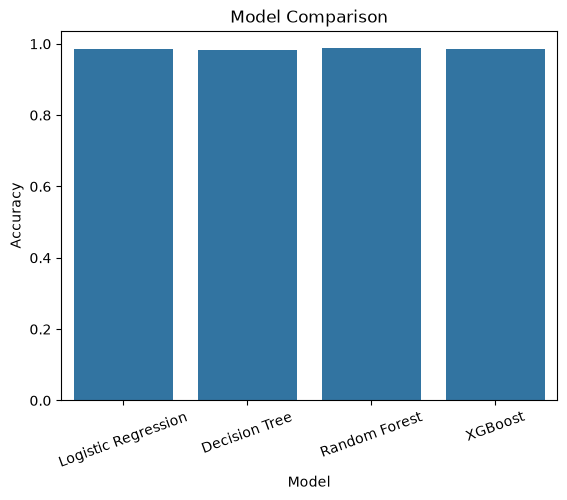

In [77]:
sns.barplot(
    data=results,
    x="Model",
    y="Accuracy"
)

plt.xticks(rotation=20)

plt.title("Model Comparison")

plt.show()

## Save Best Model

In [78]:
joblib.dump(rf, "../models/credit_card_model.pkl")

['../models/credit_card_model.pkl']

# Enhanced Feature Engineering and Model Improvement

This section improves the preprocessing pipeline by creating applicant-level credit history features, merging datasets correctly, and retraining the models for better performance.

## Step 1: Explore Credit History Records

In [79]:
credit.head()

,ID,MONTHS_BALANCE,STATUS
0,5001711,0,X
1,5001711,-1,0
2,5001711,-2,0
3,5001711,-3,0
4,5001712,0,C


In [80]:
credit.shape

(1048575, 3)

In [81]:
credit.groupby("ID").size().head(10)

ID
5001711     4
5001712    19
5001713    22
5001714    15
5001715    60
5001717    22
5001718    39
5001719    43
5001720    36
5001723    31
dtype: int64

## Step 2: Create Credit History Summary Features

In [82]:
credit_summary = credit.groupby("ID").agg(
    open_month=("MONTHS_BALANCE", "min"),
    end_month=("MONTHS_BALANCE", "max"),
    window=("MONTHS_BALANCE", "count")
)

credit_summary.head()

,open_month,end_month,window
ID,,,
5001711,-3,0,4
5001712,-18,0,19
5001713,-21,0,22
5001714,-14,0,15
5001715,-59,0,60


In [83]:
credit_summary = credit_summary.reset_index()

credit_summary.head()

,ID,open_month,end_month,window
0,5001711,-3,0,4
1,5001712,-18,0,19
2,5001713,-21,0,22
3,5001714,-14,0,15
4,5001715,-59,0,60


## Step 3: Create Approval Target

In [84]:
credit["TARGET"] = credit["STATUS"].apply(
    lambda x: 1 if x in ["1", "2", "3", "4", "5"] else 0
)

In [85]:
credit[["STATUS", "TARGET"]].head(10)

,STATUS,TARGET
0,X,0
1,0,0
2,0,0
3,0,0
4,C,0
5,C,0
6,C,0
7,C,0
8,C,0
9,C,0


In [86]:
target = credit.groupby("ID")["TARGET"].max().reset_index()

target.head()

,ID,TARGET
0,5001711,0
1,5001712,0
2,5001713,0
3,5001714,0
4,5001715,0


## Step 4: Merge the Datasets

In [87]:
df_final = application.merge(
    credit_summary,
    on="ID",
    how="inner"
)

In [88]:
df_final = df_final.merge(
    target,
    on="ID",
    how="inner"
)

In [89]:
df_final.head()

,ID,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,...,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,AGE,YEARS_EMPLOYED,open_month,end_month,window,TARGET
0,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,...,0,0,NaN,2.0,32,12,-15,0,16,1
1,5008805,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,...,0,0,NaN,2.0,32,12,-14,0,15,1
2,5008806,M,Y,Y,0,112500.0,Working,Secondary / secondary special,Married,House / apartment,...,0,0,Security staff,2.0,58,3,-29,0,30,0
3,5008808,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,...,1,1,Sales staff,1.0,52,8,-4,0,5,0
4,5008809,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,...,1,1,Sales staff,1.0,52,8,-26,-22,5,0


In [90]:
df_final.shape

(36457, 22)

In [91]:
df_final.info()

<class 'pandas.DataFrame'>
RangeIndex: 36457 entries, 0 to 36456
Data columns (total 22 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   36457 non-null  int64  
 1   CODE_GENDER          36457 non-null  str    
 2   FLAG_OWN_CAR         36457 non-null  str    
 3   FLAG_OWN_REALTY      36457 non-null  str    
 4   CNT_CHILDREN         36457 non-null  int64  
 5   AMT_INCOME_TOTAL     36457 non-null  float64
 6   NAME_INCOME_TYPE     36457 non-null  str    
 7   NAME_EDUCATION_TYPE  36457 non-null  str    
 8   NAME_FAMILY_STATUS   36457 non-null  str    
 9   NAME_HOUSING_TYPE    36457 non-null  str    
 10  FLAG_MOBIL           36457 non-null  int64  
 11  FLAG_WORK_PHONE      36457 non-null  int64  
 12  FLAG_PHONE           36457 non-null  int64  
 13  FLAG_EMAIL           36457 non-null  int64  
 14  OCCUPATION_TYPE      25134 non-null  str    
 15  CNT_FAM_MEMBERS      36457 non-null  float64
 1

# Improved Model Training

In [92]:
from sklearn.preprocessing import LabelEncoder
import joblib, os

categorical_columns = df_final.select_dtypes(include="object").columns.tolist()

encoders = {}
for col in categorical_columns:
    le = LabelEncoder()
    df_final[col] = le.fit_transform(df_final[col])
    encoders[col] = le

print(encoders.keys())

os.makedirs("../models", exist_ok=True)
joblib.dump(encoders, "../models/encoders.pkl")
print("Encoders saved successfully!")

dict_keys(['CODE_GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE', 'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE', 'OCCUPATION_TYPE'])
Encoders saved successfully!


C:\Users\Rasmitha Kasvi\AppData\Local\Temp\ipykernel_18968\3263949478.py:4: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns = df_final.select_dtypes(include="object").columns.tolist()


In [93]:
df_final.info()

<class 'pandas.DataFrame'>
RangeIndex: 36457 entries, 0 to 36456
Data columns (total 22 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   36457 non-null  int64  
 1   CODE_GENDER          36457 non-null  int64  
 2   FLAG_OWN_CAR         36457 non-null  int64  
 3   FLAG_OWN_REALTY      36457 non-null  int64  
 4   CNT_CHILDREN         36457 non-null  int64  
 5   AMT_INCOME_TOTAL     36457 non-null  float64
 6   NAME_INCOME_TYPE     36457 non-null  int64  
 7   NAME_EDUCATION_TYPE  36457 non-null  int64  
 8   NAME_FAMILY_STATUS   36457 non-null  int64  
 9   NAME_HOUSING_TYPE    36457 non-null  int64  
 10  FLAG_MOBIL           36457 non-null  int64  
 11  FLAG_WORK_PHONE      36457 non-null  int64  
 12  FLAG_PHONE           36457 non-null  int64  
 13  FLAG_EMAIL           36457 non-null  int64  
 14  OCCUPATION_TYPE      36457 non-null  int64  
 15  CNT_FAM_MEMBERS      36457 non-null  float64
 1

In [94]:
df_final.isnull().sum()

ID                     0
CODE_GENDER            0
FLAG_OWN_CAR           0
FLAG_OWN_REALTY        0
CNT_CHILDREN           0
AMT_INCOME_TOTAL       0
NAME_INCOME_TYPE       0
NAME_EDUCATION_TYPE    0
NAME_FAMILY_STATUS     0
NAME_HOUSING_TYPE      0
FLAG_MOBIL             0
FLAG_WORK_PHONE        0
FLAG_PHONE             0
FLAG_EMAIL             0
OCCUPATION_TYPE        0
CNT_FAM_MEMBERS        0
AGE                    0
YEARS_EMPLOYED         0
open_month             0
end_month              0
window                 0
TARGET                 0
dtype: int64

In [95]:
X = df_final.drop(["TARGET", "open_month", "end_month", "window"], axis=1)
y = df_final["TARGET"]

In [96]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [97]:
print(X_train.shape)
print(X_test.shape)

(29165, 18)
(7292, 18)


## Logistic Regression

In [98]:
lr = LogisticRegression(max_iter=1000)

lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)

print("Accuracy:", accuracy_score(y_test, lr_pred))

print(classification_report(y_test, lr_pred))

Accuracy: 0.8823368074602304
              precision    recall  f1-score   support

           0       0.88      1.00      0.94      6434
           1       0.00      0.00      0.00       858

    accuracy                           0.88      7292
   macro avg       0.44      0.50      0.47      7292
weighted avg       0.78      0.88      0.83      7292



c:\Users\Rasmitha Kasvi\OneDrive\Desktop\Credit-Card-Approval-Prediction\venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Rasmitha Kasvi\OneDrive\Desktop\Credit-Card-Approval-Prediction\venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Rasmitha Kasvi\OneDrive\Desktop\Credit-Card-Approval-Prediction\venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Us

## Decision Tree

In [99]:
dt = DecisionTreeClassifier(random_state=42)

dt.fit(X_train, y_train)

dt_pred = dt.predict(X_test)

print("Accuracy:", accuracy_score(y_test, dt_pred))

print(classification_report(y_test, dt_pred))

Accuracy: 0.8512068019747668
              precision    recall  f1-score   support

           0       0.92      0.91      0.92      6434
           1       0.37      0.39      0.38       858

    accuracy                           0.85      7292
   macro avg       0.65      0.65      0.65      7292
weighted avg       0.85      0.85      0.85      7292



## Random Forest

In [100]:
rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

print("Accuracy:", accuracy_score(y_test, rf_pred))

print(classification_report(y_test, rf_pred))

Accuracy: 0.8625891387822271
              precision    recall  f1-score   support

           0       0.92      0.93      0.92      6434
           1       0.40      0.36      0.38       858

    accuracy                           0.86      7292
   macro avg       0.66      0.64      0.65      7292
weighted avg       0.86      0.86      0.86      7292



## XGBoost

In [101]:
xgb = XGBClassifier(
    random_state=42,
    eval_metric="logloss"
)

xgb.fit(X_train, y_train)

xgb_pred = xgb.predict(X_test)

print("Accuracy:", accuracy_score(y_test, xgb_pred))

print(classification_report(y_test, xgb_pred))

Accuracy: 0.8868623148656062
              precision    recall  f1-score   support

           0       0.89      0.99      0.94      6434
           1       0.59      0.13      0.21       858

    accuracy                           0.89      7292
   macro avg       0.74      0.56      0.57      7292
weighted avg       0.86      0.89      0.85      7292



In [102]:
results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest",
        "XGBoost"
    ],
    "Accuracy": [
        accuracy_score(y_test, lr_pred),
        accuracy_score(y_test, dt_pred),
        accuracy_score(y_test, rf_pred),
        accuracy_score(y_test, xgb_pred)
    ]
})

results

,Model,Accuracy
0,Logistic Regression,0.882337
1,Decision Tree,0.851207
2,Random Forest,0.862589
3,XGBoost,0.886862


In [103]:
results.sort_values(
    by="Accuracy",
    ascending=False
)

,Model,Accuracy
3,XGBoost,0.886862
0,Logistic Regression,0.882337
2,Random Forest,0.862589
1,Decision Tree,0.851207


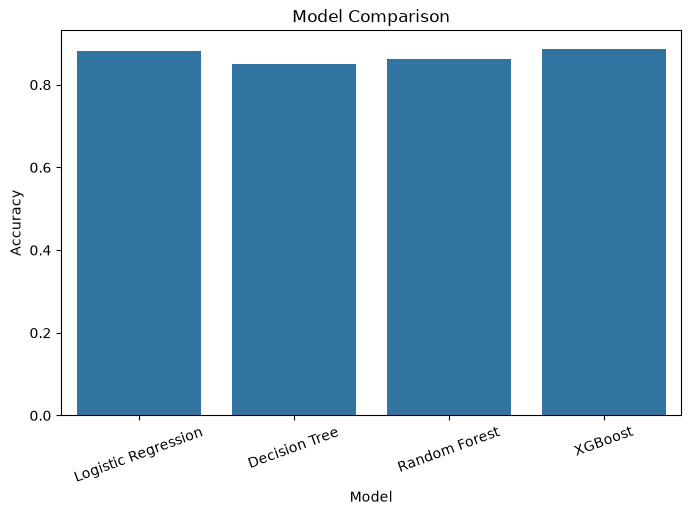

In [104]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=results,
    x="Model",
    y="Accuracy"
)

plt.title("Model Comparison")

plt.xticks(rotation=20)

plt.show()

In [105]:
best_model = rf

In [106]:
import os
import joblib

os.makedirs("../models", exist_ok=True)

joblib.dump(best_model, "../models/credit_card_model.pkl")

print("Final model saved successfully!")

Final model saved successfully!


In [107]:
import joblib

model = joblib.load("../models/credit_card_model.pkl")

print(type(model))

<class 'sklearn.ensemble._forest.RandomForestClassifier'>


In [108]:
print(X.columns.tolist())

['ID', 'CODE_GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'CNT_CHILDREN', 'AMT_INCOME_TOTAL', 'NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE', 'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE', 'FLAG_MOBIL', 'FLAG_WORK_PHONE', 'FLAG_PHONE', 'FLAG_EMAIL', 'OCCUPATION_TYPE', 'CNT_FAM_MEMBERS', 'AGE', 'YEARS_EMPLOYED']


In [109]:
application["NAME_INCOME_TYPE"].unique()

<StringArray>
['Working', 'Commercial associate', 'Pensioner', 'State servant', 'Student']
Length: 5, dtype: str

In [110]:
application["NAME_EDUCATION_TYPE"].unique()

<StringArray>
[             'Higher education', 'Secondary / secondary special',
             'Incomplete higher',               'Lower secondary',
               'Academic degree']
Length: 5, dtype: str

In [111]:
application["NAME_FAMILY_STATUS"].unique()

<StringArray>
['Civil marriage', 'Married', 'Single / not married', 'Separated', 'Widow']
Length: 5, dtype: str

In [112]:
application["NAME_HOUSING_TYPE"].unique()

<StringArray>
[   'Rented apartment',   'House / apartment', 'Municipal apartment',
        'With parents',     'Co-op apartment',    'Office apartment']
Length: 6, dtype: str

In [113]:
application["OCCUPATION_TYPE"].unique()

<StringArray>
[                    nan,        'Security staff',           'Sales staff',
           'Accountants',              'Laborers',              'Managers',
               'Drivers',            'Core staff', 'High skill tech staff',
        'Cleaning staff', 'Private service staff',         'Cooking staff',
    'Low-skill Laborers',        'Medicine staff',           'Secretaries',
  'Waiters/barmen staff',              'HR staff',         'Realty agents',
              'IT staff']
Length: 19, dtype: str

In [114]:
joblib.load("../models/encoders.pkl")

{'CODE_GENDER': LabelEncoder(),
 'FLAG_OWN_CAR': LabelEncoder(),
 'FLAG_OWN_REALTY': LabelEncoder(),
 'NAME_INCOME_TYPE': LabelEncoder(),
 'NAME_EDUCATION_TYPE': LabelEncoder(),
 'NAME_FAMILY_STATUS': LabelEncoder(),
 'NAME_HOUSING_TYPE': LabelEncoder(),
 'OCCUPATION_TYPE': LabelEncoder()}

In [115]:
df_final.head()

,ID,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,...,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,AGE,YEARS_EMPLOYED,open_month,end_month,window,TARGET
0,5008804,1,1,1,0,427500.0,4,1,0,4,...,0,0,18,2.0,32,12,-15,0,16,1
1,5008805,1,1,1,0,427500.0,4,1,0,4,...,0,0,18,2.0,32,12,-14,0,15,1
2,5008806,1,1,1,0,112500.0,4,4,1,1,...,0,0,16,2.0,58,3,-29,0,30,0
3,5008808,0,0,1,0,270000.0,0,4,3,1,...,1,1,14,1.0,52,8,-4,0,5,0
4,5008809,0,0,1,0,270000.0,0,4,3,1,...,1,1,14,1.0,52,8,-26,-22,5,0


In [116]:
print(df["CODE_GENDER"].unique())
print(df["FLAG_OWN_CAR"].unique())
print(df["FLAG_OWN_REALTY"].unique())

print(df["NAME_INCOME_TYPE"].unique())
print(df["NAME_EDUCATION_TYPE"].unique())
print(df["NAME_FAMILY_STATUS"].unique())
print(df["NAME_HOUSING_TYPE"].unique())
print(df["OCCUPATION_TYPE"].unique())

[1 0]
[1 0]
[1 0]
[4 0 1 2 3]
[1 4 2 3 0]
[0 1 3 2 4]
[4 1 2 5 0 3]
[18 16 14  0  8 10  4  3  6  1 12  2  9 11 15 17  5 13  7]


In [117]:
print(df_final["TARGET"].value_counts())

TARGET
0    32166
1     4291
Name: count, dtype: int64


In [118]:
pred = best_model.predict(X_test)

import numpy as np
print(np.unique(pred, return_counts=True))

(array([0, 1]), array([6536,  756]))


In [119]:
print(X.head())

        ID  CODE_GENDER  FLAG_OWN_CAR  FLAG_OWN_REALTY  CNT_CHILDREN  \
0  5008804            1             1                1             0   
1  5008805            1             1                1             0   
2  5008806            1             1                1             0   
3  5008808            0             0                1             0   
4  5008809            0             0                1             0   

   AMT_INCOME_TOTAL  NAME_INCOME_TYPE  NAME_EDUCATION_TYPE  \
0          427500.0                 4                    1   
1          427500.0                 4                    1   
2          112500.0                 4                    4   
3          270000.0                 0                    4   
4          270000.0                 0                    4   

   NAME_FAMILY_STATUS  NAME_HOUSING_TYPE  FLAG_MOBIL  FLAG_WORK_PHONE  \
0                   0                  4           1                1   
1                   0                  4        